# Supplementary Figure S6: Validation and characterization of backbone and sugar-pucker assessment

(A) Agreement between PARSE-calculated backbone suiteness and corresponding PDB
RNA suiteness values across 2,605 non-redundant RNA structures. (B) Richardson
suite-conformer usage within each Leontis-Westhof interaction class, expressed
as the percentage of residues assigned to each conformer, demonstrating
class-dependent differences in backbone conformational preferences.
(C) Suiteness before and after applying torsional corrections recommended by
PARSE, illustrating the potential improvement in backbone suiteness following
correction of torsions associated with low-suiteness conformations.
(D) Relationship between delta torsion and Pperp for helical cWW G-C/A-U pairs.
PARSE flags pucker outliers when delta torsion and Pperp give discordant
assignments, while unusual puckers are identified specifically as C2'-endo
conformations occurring in otherwise canonical helical cWW G-C/A-U pairs. These
complementary criteria distinguish inconsistent sugar-pucker assignments from
structurally unusual puckers.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

_ROOT = Path.cwd().parent.parent
_SUB = "supplemental" if Path.cwd().name == "supplemental_figures" else "main"
FIGURES = _ROOT / "figures" / _SUB

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / _SUB / name

TORS = pd.read_csv(data_file("reference/high_quality_features/torsions.csv"))
TORS["is_outlier"] = TORS["is_outlier"].fillna(False).astype(bool)

TORS = TORS[TORS.res_id.str.split("-").str[1].isin(["A", "C", "G", "U"])]
LW = ["cWW", "tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]
RES = TORS[TORS.lw_class.isin(LW)].copy()

print(f"{len(RES):,} residues in a classified pair, from "
      f"{RES.pdb_id.nunique():,} high-quality structures")


727,448 residues in a classified pair, from 940 high-quality structures


## (A) Backbone suiteness against the deposited PDB value

Both are Richardson 2008 suiteness, natively a 0-1 fraction: PARSE computes it
from the structure, the wwPDB validation report ships `rnasuiteness` with the
entry.

saved figures/supplemental/figS6_A_suiteness_vs_pdb.png


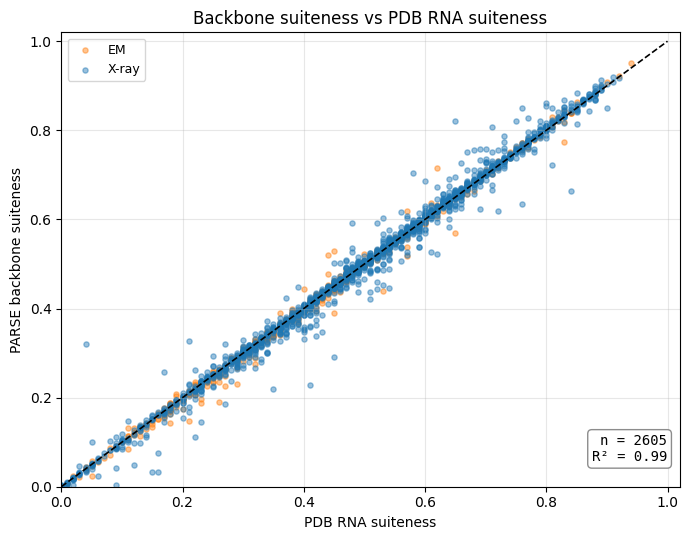

In [2]:
SC = json.load(open(data_file("reference/scores/scores_all_uniques.json")))["scores"]
VM = json.load(open(data_file("reference/metadata/metadata_cache.json")))["validation_metrics"]

rows = []
for pdb, info in SC.items():
    if not isinstance(info, dict):
        continue
    m = VM.get(pdb) or {}
    ours, theirs = info.get("backbone_suiteness"), m.get("rnasuiteness")
    if ours is None or theirs is None:
        continue
    rows.append({"pdb": pdb, "method": m.get("Experimental_method"),
                 "parse": ours, "wwpdb": theirs})
A = pd.DataFrame(rows)

r2 = lambda d: np.corrcoef(d.wwpdb, d.parse)[0, 1] ** 2

METHOD_COLORS = {"X-ray": "tab:blue", "EM": "tab:orange"}

fig, ax = plt.subplots(figsize=(7, 5.5))

for method, sub in A.groupby("method"):
    ax.scatter(sub.wwpdb, sub.parse,
               s=14, alpha=0.45, color=METHOD_COLORS.get(method, "gray"), label=method)

ax.plot([0, 1], [0, 1], color="black", lw=1.2, ls="--")

ax.text(0.98, 0.05, f"n = {len(A)}\nR\u00b2 = {r2(A):.2f}",
        transform=ax.transAxes, ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9),
        fontsize=10, family="monospace")

ax.set_xlabel("PDB RNA suiteness")
ax.set_ylabel("PARSE backbone suiteness")
ax.set_title("Backbone suiteness vs PDB RNA suiteness")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
print("saved", savefig(fig, "figS6_A_suiteness_vs_pdb.png"))
plt.show()


R-squared 0.99 over 2,605 structures. The points lie on the identity line, not
merely correlated with it.

## (B) Suite-conformer usage within each pair class

For every residue in a classified pair, the named Richardson rotamer its
backbone sits in. Restricted to standard ribonucleotides in the curated
high-quality set, since a conformer assignment is only as good as the torsions
behind it.

saved figures/supplemental/figS6_B_conformer_usage_by_class.png


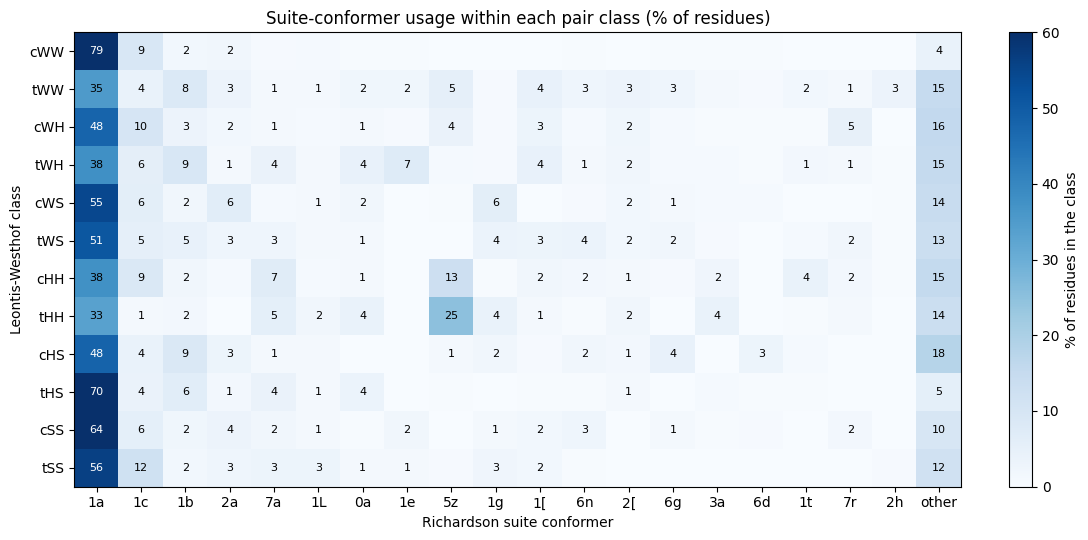

,n residues,outlier %,top conformers
class,,,
cWW,454907,10.9,"1a 79%, 1c 9%, 2a 2%, 1b 2%"
tWW,10076,33.3,"1a 35%, 1b 8%, 5z 5%, 1[ 4%"
cWH,12781,29.1,"1a 48%, 1c 10%, 7r 5%, 5z 4%"
tWH,31435,24.3,"1a 38%, 1b 9%, 1e 7%, 1c 6%"
cWS,17279,21.7,"1a 55%, 2a 6%, 1g 6%, 1c 6%"
tWS,13158,23.3,"1a 51%, 1c 5%, 1b 5%, 6n 4%"
cHH,1265,36.1,"1a 38%, 5z 13%, 1c 9%, 7a 7%"
tHH,7492,21.0,"1a 33%, 5z 25%, 7a 5%, 0a 4%"
cHS,5107,21.5,"1a 48%, 1b 9%, 6g 4%, 1c 4%"


In [3]:
assigned = RES[~RES.is_outlier]
tab = pd.crosstab(assigned.lw_class, assigned.conformer).reindex(LW).dropna(how="all")
share = 100 * tab.div(tab.sum(axis=1), axis=0)
top = list(tab.sum(axis=0).sort_values(ascending=False).head(12).index)
top += [c for c in share.columns[share.max(axis=0) >= 3] if c not in top]
top = sorted(top, key=lambda c: -tab[c].sum())
use = share[top].copy()
use["other"] = 100 - use.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(use.values, cmap="Blues", vmin=0, vmax=60, aspect="auto")
ax.set_xticks(range(use.shape[1])); ax.set_xticklabels(use.columns)
ax.set_yticks(range(use.shape[0])); ax.set_yticklabels(use.index)
ax.set_xlabel("Richardson suite conformer"); ax.set_ylabel("Leontis-Westhof class")
ax.set_title("Suite-conformer usage within each pair class (% of residues)")
for i in range(use.shape[0]):
    for j in range(use.shape[1]):
        v = use.values[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if v > 40 else "black")
fig.colorbar(im, ax=ax, fraction=0.025, label="% of residues in the class")
fig.tight_layout()
print("saved", savefig(fig, "figS6_B_conformer_usage_by_class.png"))
plt.show()

rows = []
for r in LW:
    d = assigned[assigned.lw_class == r]
    if len(d) < 200:
        continue
    vc = d.conformer.value_counts(normalize=True)
    rows.append({"class": r, "n residues": len(d),
                 "outlier %": round(100 * RES.loc[RES.lw_class == r, "is_outlier"].mean(), 1),
                 "top conformers": ", ".join(f"{k} {100*v:.0f}%" for k, v in vc.head(4).items())})
display(pd.DataFrame(rows).set_index("class"))


`1a` leads every class, and `5z` is used substantially only by the Hoogsteen-Hoogsteen classes.

## (C) Suiteness before and after PARSE's recommended corrections

For a residue with poor backbone, PARSE assigns a target conformer and
recommends correcting the torsions whose ProSco has fired.

The test is on residues with an assigned rotamer, suiteness under 0.5, and at
least one recommended torsion. Those torsions are snapped to their targets and
the residue re-scored with the Richardson classifier.

saved figures/supplemental/figS6_C_recommended_corrections.png


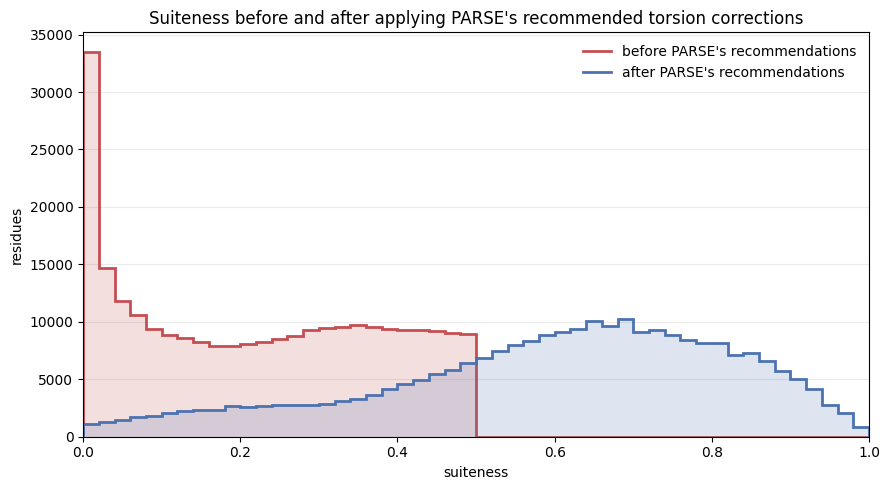

257,856 residues: mean suiteness 0.22 -> 0.59, 70.2% cross 0.5


In [4]:
B = pd.read_csv(data_file("reference/backbone_recommendations.csv"))
fx = B[B.tier == "fixable"]

bins = np.linspace(0, 1, 51)
fig, ax = plt.subplots(figsize=(9, 5))
for v, lab, colr in ((fx.suiteness, "before PARSE's recommendations", "#C44E52"),
                     (fx.suiteness_after, "after PARSE's recommendations", "#4C72B0")):
    h, e = np.histogram(v, bins=bins)
    ax.stairs(h, e, fill=True, alpha=0.18, color=colr)
    ax.stairs(h, e, lw=2, color=colr, label=lab)
ax.set_xlim(0, 1)
ax.set_xlabel("suiteness"); ax.set_ylabel("residues")
ax.set_title("Suiteness before and after applying PARSE's recommended torsion corrections")
ax.legend(fontsize=10, loc="upper right", frameon=False)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
fig.tight_layout()
print("saved", savefig(fig, "figS6_C_recommended_corrections.png"))
plt.show()

print(f"{len(fx):,} residues: mean suiteness {fx.suiteness.mean():.2f} -> "
      f"{fx.suiteness_after.mean():.2f}, {100*(fx.suiteness_after > 0.5).mean():.1f}% "
      "cross 0.5")

Correcting only the torsions PARSE recommends, a median of one per residue,
moves 70% of them past suiteness 0.5. Snapping toward a cluster centre can only
raise suiteness and each residue is corrected independently, so these are
per-residue upper bounds.

## (D) The two sugar-pucker flags

PARSE reports two pucker flags. Neither affects the score.

- **Pucker outlier**: delta and Pperp disagree about the pucker of a residue.
  They are independent measures of the same thing, so a disagreement means the
  ribose is mis-modelled.
- **Unusual pucker**: a C2'-endo sugar in a helical canonical cWW G-C/A-U pair,
  where A-form geometry demands C3'-endo. Each one carries a Pperp cross-check:
  confirmed means a genuine but atypical sugar, contradicted means a
  mis-modelled one.

Delta is the ribose ring torsion, taken from the modelled sugar. Pperp is the
perpendicular dropped from the 3' phosphate onto the glycosidic bond vector.

saved figures/supplemental/figS6_D_delta_vs_pperp.png


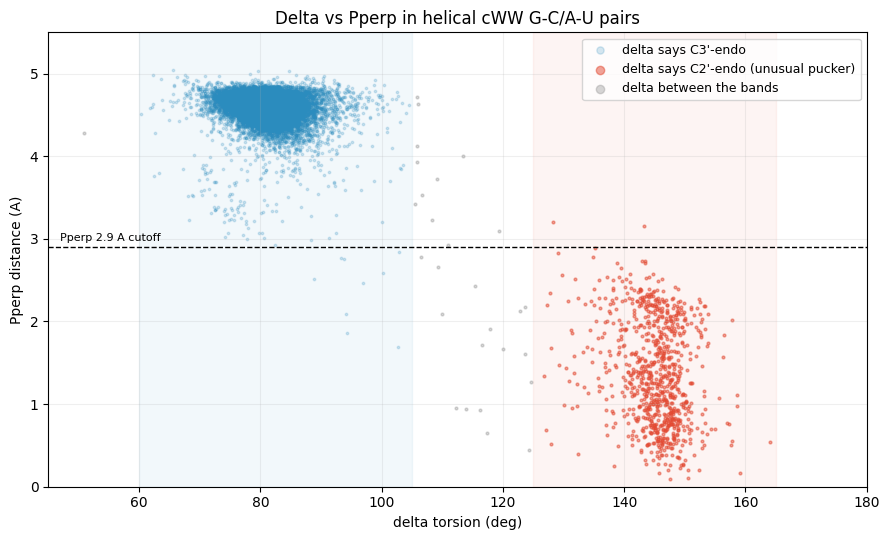

In [5]:
PP = np.load(data_file("reference/pucker_delta_pperp_hist.npz"))
counts, d_edges, p_edges = PP["hist_helical"], PP["delta_edges"], PP["pperp_edges"]

rng = np.random.default_rng(1)
frac = 40_000 / counts.sum()
dx, px = [], []
for i in range(counts.shape[0]):
    for j in np.nonzero(counts[i])[0]:
        k = rng.binomial(int(counts[i, j]), frac)
        if k:
            dx.append(rng.uniform(d_edges[i], d_edges[i + 1], k))
            px.append(rng.uniform(p_edges[j], p_edges[j + 1], k))
dx, px = np.concatenate(dx), np.concatenate(px)
band = np.where((dx >= 60) & (dx <= 105), 3, np.where((dx >= 125) & (dx <= 165), 2, 0))

fig, ax = plt.subplots(figsize=(9, 5.5))
for b, colr, s, al, lab in ((3, "#2b8cbe", 3, 0.2, "delta says C3'-endo"),
                            (2, "#e34a33", 4, 0.5, "delta says C2'-endo (unusual pucker)"),
                            (0, "#999999", 4, 0.4, "delta between the bands")):
    ax.scatter(dx[band == b], px[band == b], s=s, alpha=al, color=colr, label=lab)
ax.axhline(2.9, ls="--", color="k", lw=1)
ax.text(47, 2.98, "Pperp 2.9 A cutoff", fontsize=8)
ax.axvspan(60, 105, color="#2b8cbe", alpha=0.06)
ax.axvspan(125, 165, color="#e34a33", alpha=0.06)
ax.set_xlim(45, 180); ax.set_ylim(0, 5.5)
ax.set_xlabel("delta torsion (deg)"); ax.set_ylabel("Pperp distance (A)")
ax.set_title("Delta vs Pperp in helical cWW G-C/A-U pairs")
ax.legend(loc="upper right", fontsize=9, markerscale=3); ax.grid(alpha=0.2)
fig.tight_layout()
print("saved", savefig(fig, "figS6_D_delta_vs_pperp.png"))
plt.show()

PUCK = [json.loads(l) for l in open(data_file("reference/pucker_uniques.jsonl"))]
unusual = [f for r in PUCK for f in r["unusual_pucker"]]
outliers = [f for r in PUCK for f in r["pucker_outliers"]]
confirmed = 100 * np.mean([f["pperp_confirms"] for f in unusual])

Jain, Richardson & Richardson: the Pperp distance "reliably indicates the pucker
of the ribose ring: it is long for C3'-endo pucker and short for C2'-endo
pucker", and it holds even for misfit models, so pairing it against delta tells
you whether a modelled pucker is correct.

PARSE flags a residue as a **pucker outlier** when delta and Pperp disagree on
its pucker.

PARSE flags a **C2'-endo sugar in a helical canonical cWW G-C/A-U pair** as an
unusual pucker, and the Pperp cross-check says whether it is genuine or
mis-modelled.